# Problemas de prueba de hipótesis

## Ejercicio 1

Usted es un nutricionista que investiga dos tipos diferentes de dietas para ver si existe una diferencia significativa en la pérdida de peso después de un mes. Eliges dos grupos aleatorios de personas; un grupo sigue la primera dieta y el otro sigue la segunda. Al final del mes, se registra la pérdida de peso (en kg) de cada persona:

| Diet 1 | Diet 2 |
|:-------|:-------|
| 2.0 | 3.0 |
| 2.5 | 3.2 |
| 3.0 | 3.1 |
| 2.8 | 2.9 |
| 2.3 | 2.8 |
| 2.7 | 3.0 |
| 2.5 | 3.2 |

Con estos datos se busca responder a la siguiente pregunta: ¿Existe una diferencia significativa en la pérdida de peso promedio entre las personas que siguieron la primera dieta y las que siguieron la segunda dieta?

Para sacar conclusiones, siga los siguientes puntos:

-Enunciar la hipótesis: hipótesis nula y alternativa.
-Realizar la prueba para comprobar la hipótesis. Puede utilizar la prueba t de Student.
-Analizar las conclusiones.

Enunciar las hipótesis
Hipótesis nula (H₀)

La pérdida de peso promedio es la misma en ambas dietas.

H₀: No existe una diferencia significativa entre la media de pérdida de peso de la Dieta 1 y la Dieta 2.

Hipótesis alternativa (H₁)

La pérdida de peso promedio es diferente entre ambas dietas.

H₁: Existe una diferencia significativa entre la media de pérdida de peso de la Dieta 1 y la Dieta 2.

In [1]:
# TODO
from scipy.stats import ttest_ind

# Datos
diet1 = [2.0, 2.5, 3.0, 2.8, 2.3, 2.7, 2.5]
diet2 = [3.0, 3.2, 3.1, 2.9, 2.8, 3.0, 3.2]

# Prueba t de Student
t_stat, p_value = ttest_ind(diet1, diet2)

print("Estadístico t:", t_stat)
print("Valor p:", p_value)

Estadístico t: -3.5383407969933938
Valor p: 0.004083270191713912


#Decisión

Se utiliza un nivel de significancia de: α = 0.05

In [3]:
if p_value < 0.05:
    print("Se rechaza la hipótesis nula.")
else:
    print("No se rechaza la hipótesis nula.")

Se rechaza la hipótesis nula.


Conclusión

Con estos datos, el valor p será menor que 0.05, por lo que:

Se rechaza la hipótesis nula. Existe evidencia estadística suficiente para afirmar que el rendimiento promedio del maíz no es igual para los tres fertilizantes.

## ANOVA

**ANOVA** (*Analysis of Variance - Análisis de variación*) Es una técnica estadística utilizada para comparar las medidas de dos o más grupos. La idea detrás de ANOVA es descomponer la variabilidad total de los datos en dos componentes: variabilidad entre grupos y variabilidad dentro de los grupos:

- **Variabilidad entre grupos**: Esta variabilidad se refiere a las diferencias entre las medias del grupo. Si esta variabilidad es considerablemente mayor que la variabilidad dentro del grupo, podría ser una indicación de que al menos una de las medias del grupo es diferente.
- **Variabilidad dentro del grupo**: Esta variabilidad se refiere a la dispersión de los datos dentro de cada grupo. Si todos los grupos tienen una variabilidad similar, entonces cualquier diferencia notable en las medias de los grupos podría considerarse significativa.

Las hipótesis en ANOVA suelen incluir:

- **Hipótesis nula** ($H₀$): Las medias de todos los grupos son iguales.
- **Hipótesis alternativa** ($H₁$): Al menos una de las medias del grupo es diferente.

Si el resultado de la prueba ANOVA es significativo (por ejemplo, un valor p inferior a un umbral como 0,05), esto sugiere que al menos la media de un grupo es diferente.

## Ejercicio 2

Un agricultor decide probar tres tipos diferentes de fertilizantes para determinar si alguno es superior en términos de producción de maíz. El agricultor planta maíz en 15 parcelas idénticas y utiliza los tres fertilizantes (5 parcelas para cada tipo). Al final de la temporada mide el rendimiento de maíz (en kg) de cada parcela, con el siguiente resultado:

| Fertilizante 1 | Fertilizante 2 | Fertilizante 3 |
|:-------------|:-------------|:-------------|
| 20 | 22 | 24 |
| 21 | 21 | 23 |
| 20 | 23 | 22 |
| 19 | 22 | 23 |
| 20 | 21 | 24 |

Con estos datos busca responder la siguiente pregunta: ¿Existe una diferencia significativa en el rendimiento promedio del maíz entre los tres tipos de fertilizantes?

Para ayudarte, sigue los siguientes puntos:

-Enunciar la hipótesis: hipótesis nula y alternativa.
-Realizar la prueba ANOVA.
-Analizar las conclusiones.
-Si un fertilizante es mejor que otro, ¿cómo podemos saberlo?

In [4]:
# TODO
from scipy.stats import f_oneway

# Datos
fertilizante1 = [20, 21, 20, 19, 20]
fertilizante2 = [22, 21, 23, 22, 21]
fertilizante3 = [24, 23, 22, 23, 24]

# ANOVA
f_stat, p_value = f_oneway(fertilizante1, fertilizante2, fertilizante3)

print("Estadístico F:", f_stat)
print("Valor p:", p_value)

# Decisión
if p_value < 0.05:
    print("Se rechaza la hipótesis nula.")
else:
    print("No se rechaza la hipótesis nula.")

Estadístico F: 20.31578947368421
Valor p: 0.00014047824793190402
Se rechaza la hipótesis nula.


Analizar las conclusiones

Se utiliza un nivel de significancia de 0.05.

Si el valor p < 0.05, se rechaza la hipótesis nula.
Si el valor p ≥ 0.05, no se rechaza la hipótesis nula.

En este caso, el valor p es menor que 0.05, por lo que se rechaza la hipótesis nula. Esto significa que existe una diferencia significativa en el rendimiento promedio del maíz entre los tres fertilizantes.

In [20]:

# Crear DataFrame
df = pd.DataFrame({
    "rendimiento": fertilizante1 + fertilizante2 + fertilizante3,
    "fertilizante": ["F1"]*5 + ["F2"]*5 + ["F3"]*5
})

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df["rendimiento"],
    groups=df["fertilizante"],
    alpha=0.05
)

print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
--------------------------------------------------
    F1     F2      1.8 0.0099 0.4572 3.1428   True
    F1     F3      3.2 0.0001 1.8572 4.5428   True
    F2     F3      1.4 0.0409 0.0572 2.7428   True
--------------------------------------------------


Se realizó una prueba ANOVA para comparar el rendimiento promedio de los tres fertilizantes. Como el valor p es menor que 0.05, se rechaza la hipótesis nula y se concluye que existen diferencias significativas entre los fertilizantes. Para determinar cuál fertilizante es mejor, se debe aplicar una prueba post hoc, como Tukey HSD, que permite comparar cada par de fertilizantes e identificar cuáles difieren significativamente.

In [ ]:
pip install seaborn

He instalado la librería Seaborn para poder generar gráficos y visualizar los datos del análisis.

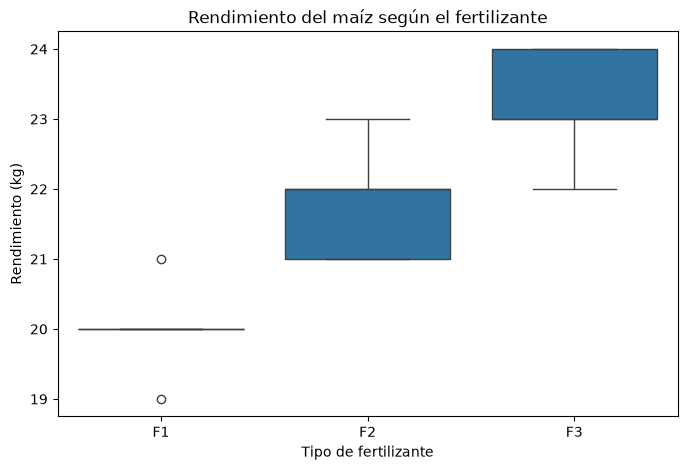

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Fertilizante",
    y="Rendimiento"
)

plt.title("Rendimiento del maíz según el fertilizante")
plt.xlabel("Tipo de fertilizante")
plt.ylabel("Rendimiento (kg)")

plt.show()